# Name: benhur dabre
# Roll no: 12
# Class/Batch: Se Aiml / B-1
# Expt.-8: Clustering of Countries with World Bank API

In [ ]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Part 1: Dataset

In [ ]:
def fetch_indicator(code, year = "2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=3000"
  response = requests.get(url).json()[1]

  data = {}
  for item in response:
    country = item["country"]["value"]
    value = item["value"]
    if  value is not None:
      data[country] = value 

  return pd.Series(data, name = code)

In [ ]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [ ]:
df = pd.concat([gdp, pop, life, lit], axis = 1)

# Define new column name
df.columns = ["GDP", "Population", "LifeExpectancy", "literarcy"]

# Remove missing data
df.dropna(inplace = True)

df.head()

# print("India:", "India" in df.index)
# print(df.Loc["India"])

,GDP,Population,LifeExpectancy,literarcy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

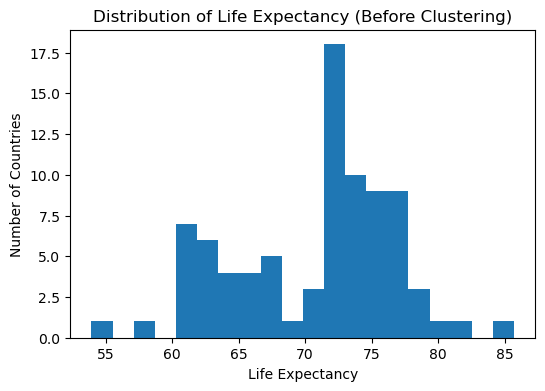

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

# Part 2

k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

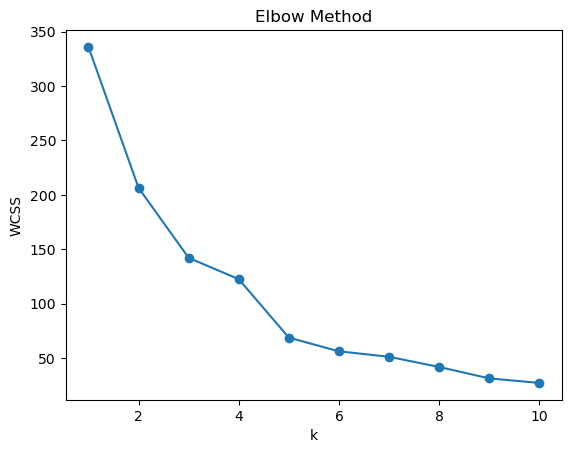

In [ ]:
wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters = k, random_state = 0)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
  print(i+1, "\t", wcss[i])

plt.plot(range(1, 11), wcss, marker = 'o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# # Part 3: Clustering Algorithm

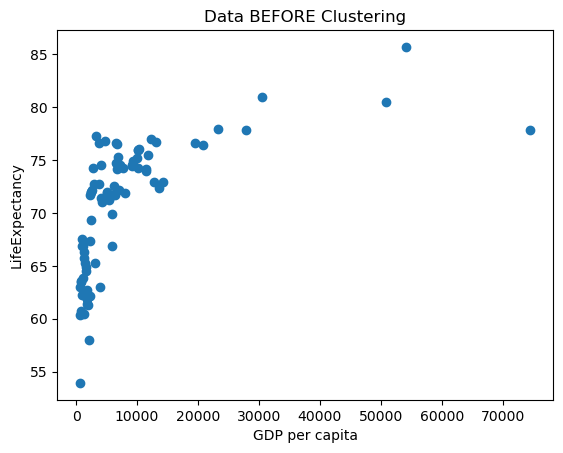

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP per capita")
plt.ylabel("LifeExpectancy")
plt.title("Data BEFORE Clustering")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 0)

# Label the clusters means give numbers to them and add it as column KmeansCluster
labels_km = kmeans.fit_predict(X_scaled)

df["KmeansCluster"] = labels_km

c:\ProgramData\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


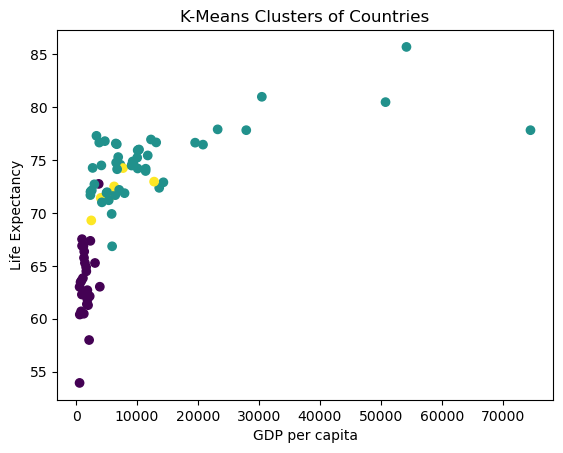

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c= labels_km)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters = 3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchicalCluster"] = labels_hc

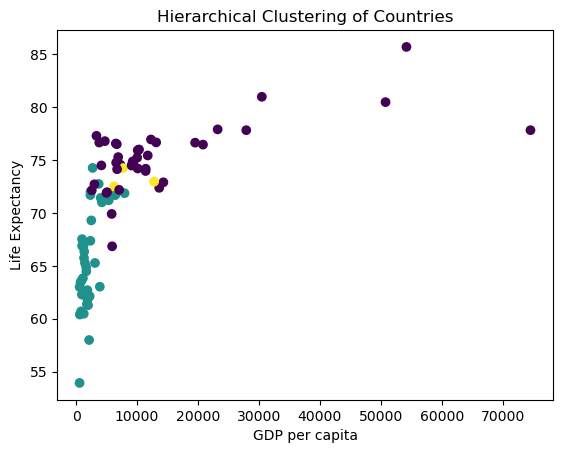

In [ ]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c= labels_hc)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clustering of Countries")
plt.show()

In [ ]:
country_name = "India"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["literarcy"])
print("K-means Cluster:", result["KmeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
K-means Cluster: 1.0
Hierarchical Cluster: 1.0


In [ ]:
country_name = "North America"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["literarcy"])
print("K-means Cluster:", result["KmeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [ ]:
country_name = "Brazil"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["literarcy"])
print("K-means Cluster:", result["KmeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [ ]:
country_name = "Viet Nam"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["literarcy"])
print("K-means Cluster:", result["KmeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [ ]:
country_name = "Bahrain"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["literarcy"])
print("K-means Cluster:", result["KmeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
K-means Cluster: 1.0
Hierarchical Cluster: 0.0


In [ ]:
cluster_summary = df.groupby("KmeansCluster") [["GDP", "Population", "LifeExpectancy", "literarcy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy  literarcy
KmeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687
